# Classification algorithms

### Dataset description, visualisation, and pre-processing

<div class="alert alert-block alert-warning">The Heart Disease Detection dataset is composed of a set of characteristics used to determine if a patient has heart disease or not. Its main purpose is to perform classification based on the target variable, 'HeartDisease,' which indicates the presence of heart disease in the patient. This variable has integer values where 0 represents no disease and 1 indicates the presence of disease.
<div/>

<div class="alert alert-block alert-danger"> 
    
1. Import the Heart Disease Detection dataset.
2. Display and try to understand each feature in this dataset.
3. Display a summary of the dataset.
4. Verify if the dataset contains any missing values.
5. Plot the distribution of samples according to the target variable HeartDisease. Determine if the dataset is balanced.
6. Apply dummy encoding to all categorical features in the dataset.
7. Display the Pearson correlation matrix. Is there a correlation with the class and between features by considering a thresholed of 0.5?
8. Display the distribution of all features on all the scaled data (except binary features) using a histplot. What do you observe?
9. Split the data into a training and a testing set using a ratio of 0.3.
10. Normalize the data using z-score scaling.
<div/>

display ds :
    Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  

summary of the dataset:
               Age   RestingBP  Cholesterol   FastingBS       MaxHR  \
count  918.000000  918.000000   918.000000  918.000000  918.000000   
mean    53.510893  132.3965

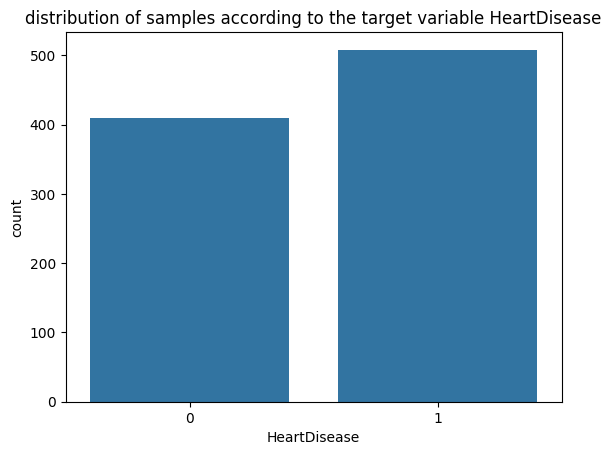

Class Distribution:
 HeartDisease
1    508
0    410
Name: count, dtype: int64

Class Proportions:
 HeartDisease
1    0.553377
0    0.446623
Name: count, dtype: float64
The dataset is imbalanced.

encoded ds
    Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease  \
0   40        140          289          0    172        0             0   
1   49        160          180          0    156        1             1   
2   37        130          283          0     98        0             0   
3   48        138          214          0    108        1             1   
4   54        150          195          0    122        0             0   

   Sex_M  ChestPainType_ATA  ChestPainType_NAP  ChestPainType_TA  \
0      1                  1                  0                 0   
1      0                  0                  1                 0   
2      1                  1                  0                 0   
3      0                  0                  0                 0   
4

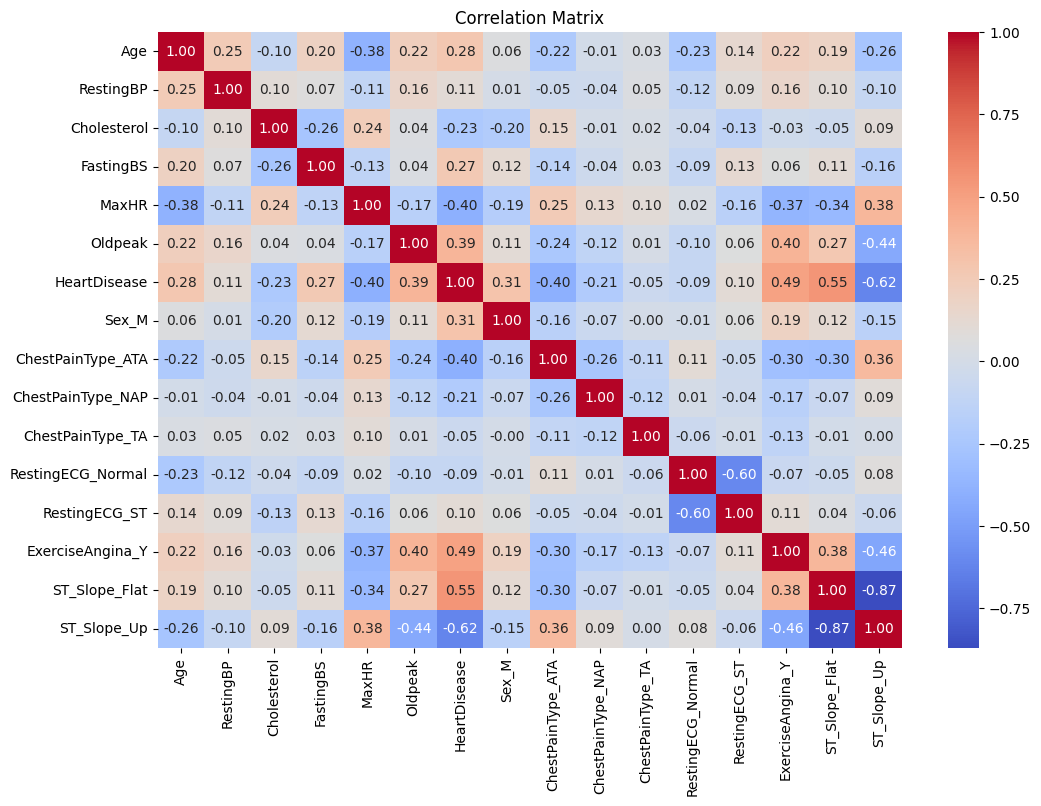


features Correlated with HeartDisease:
 HeartDisease     1.000000
ST_Slope_Flat    0.554134
ST_Slope_Up     -0.622164
Name: HeartDisease, dtype: float64


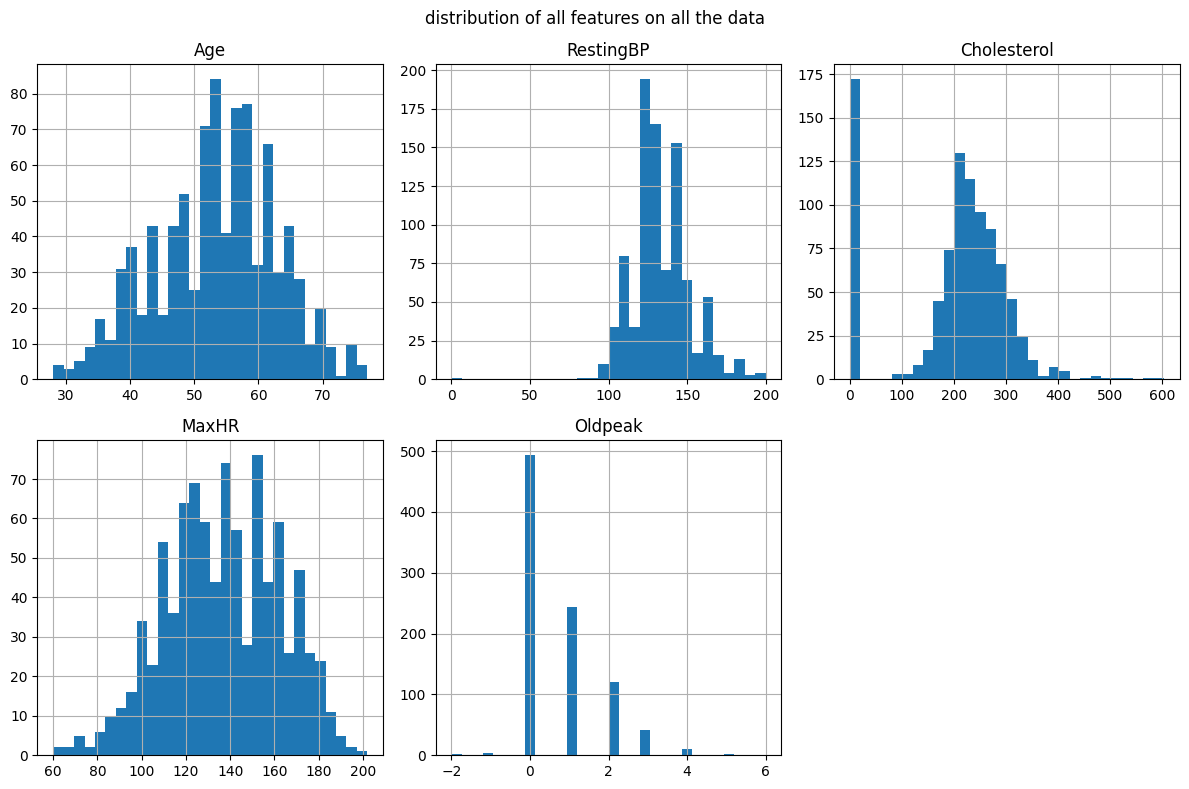


size of training set (642, 15)
size of testing set: (276, 15)

Data normalized and ready for modeling!


In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#1
data = pd.read_csv('heart.csv')

#2
print("display ds :\n", data.head())

#3

print("\nsummary of the dataset:\n", data.describe())

#4

print("\nany missing values:\n",  data.isnull().sum())

#5
sns.countplot(x='HeartDisease', data=data)
plt.title('distribution of samples according to the target variable HeartDisease')
plt.show()


class_distribution = data['HeartDisease'].value_counts()
print("Class Distribution:\n", class_distribution)

class_proportions = class_distribution / len(data)
print("\nClass Proportions:\n", class_proportions)

if abs(class_proportions[1] - class_proportions[0]) <= 0.1:
    print("The dataset is moderately balanced.")
else:
    print("The dataset is imbalanced.")

#dummy encoding => convert categorical variables into numerical form
categorical_features = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
#Converts these categorical columns into multiple binary (0/1) columns
data_encoded = pd.get_dummies(data, columns=categorical_features, drop_first=True)
data_encoded = data_encoded.astype(int)
print("\nencoded ds\n", data_encoded.head())

#7
matricecorr = data_encoded.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(matricecorr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

corrM = matricecorr['HeartDisease']
corrfeat = corrM[corrM.abs() > 0.5]
print("\nfeatures Correlated with HeartDisease:\n", corrfeat)

numfeat = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
numdata = data_encoded[numfeat]

# Scaling the features =>
# normaliser les données. Il met chaque feature à la même échelle en 
# Retirant la moyenne de chaque feature.
# Divisant par l'écart type

# scaler = StandardScaler()
# scaled_data = pd.DataFrame(scaler.fit_transform(numdata), columns=numfeat)


#8
numdata.hist(bins=30, figsize=(12, 8), layout=(2, 3))
plt.suptitle('distribution of all features on all the data')
plt.tight_layout()
plt.show()

#9
X = data_encoded.drop(columns=['HeartDisease'])
y = data_encoded['HeartDisease']
# 70% d'entraînement
# 30% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("\nsize of training set", X_train.shape)
print("size of testing set:", X_test.shape)

#10
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) #Applique la normalisation

print("\nData normalized and ready for modeling!")


### Data training and performance evaluation

<div class="alert alert-block alert-danger"> 
    
1. Train the following algorithms on the generated training dataset: Gaussian Naive Bayes, KNN(K=3), and decision tree (max_depth=6).
2. Display and save the tree generated by the decision tree algorithm.
3. Implement the SVM algorithm from scratch and apply it to the dataset.
4. Print the classification reports and confusion matrices of all models on the testing set. Discuss the obtained results.
5. Display the ROC curves of the generated models in one plot.
6. Which evaluation metric do you recommend for this dataset?
7. Predict the class of the third sample from the testing set based on the best-performing model.
8. Perform the cross-validation evaluation method on the best model based on the selected metric.
</div>

In [35]:
#fait des prédictions sur des données de test
#puis évalue à quel point ces prédictions sont correctes


from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score


gaus = GaussianNB()

#fit : pour entraine le modele , qlq modele de naive bayes besoins des données normalisé 
gaus.fit(X_train_scaled, y_train)

# Prédictions sur l'ensemble de test
y_pred_gaus = gaus.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred_gaus)
print("Gaussian Naive Bayes Accuracy:", accuracy)


Gaussian Naive Bayes Accuracy: 0.8804347826086957


In [36]:
# classifier les données de test, en se basant sur les voisins les plus proches
#3 voisins les plus proches dans X_train

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train,y_train)
y_pred_knn = knn.predict(X_test)

accuracyy = accuracy_score(y_test, y_pred_knn)

print("KNN3", accuracyy)


KNN3 0.6992753623188406


Decision Tree Accuracy: 0.8079710144927537


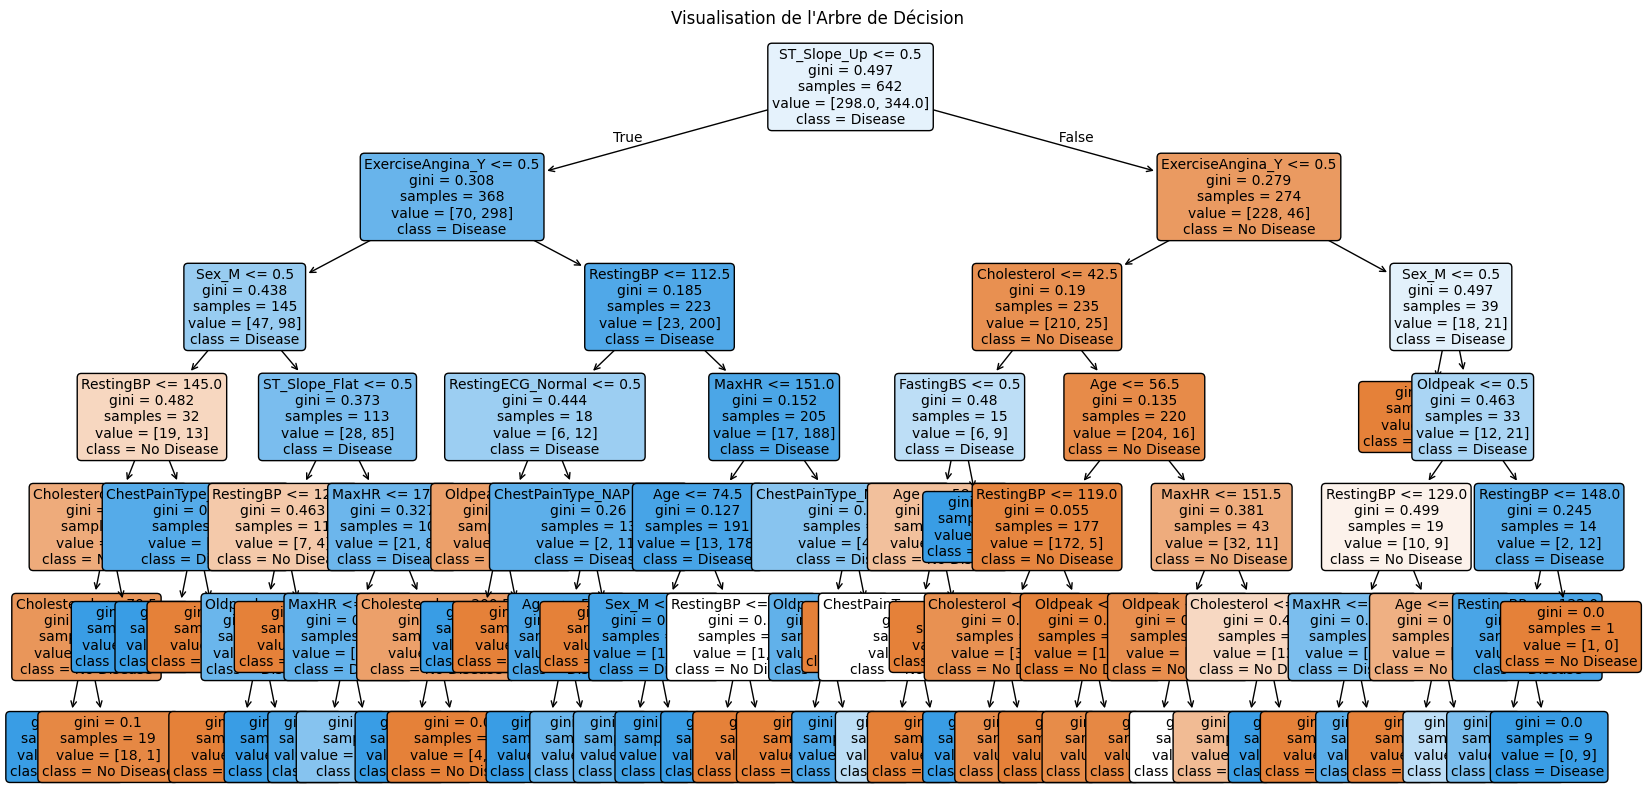

In [37]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

tree = DecisionTreeClassifier(max_depth=6)


tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

accuracyyy = accuracy_score(y_test, y_pred_tree)
print("Decision Tree Accuracy:", accuracyyy)

plt.figure(figsize=(20, 10))  # Définir la taille de la figure
plot_tree(
    tree,  # Modèle d'arbre de décision
    feature_names=X_train.columns,  # Noms des caractéristiques
    class_names=['No Disease', 'Disease'],  # Noms des classes
    filled=True,  # Coloration des nœuds
    rounded=True,  # Coins arrondis pour une meilleure esthétique
    fontsize=10  # Taille de la police
)
plt.title("Visualisation de l'Arbre de Décision")
plt.show()


In [ ]:
#--- Le SVM est une méthode de classification supervisée afin de séparer les classes
#class (line) , plusieur class (hyperline)
#--𝑤 (distance)est un vecteur qui contient un poids pour chaque caractéristique. (maximiser la distance entre line et les classes)
#--b est une constante qui déplace l’hyperplan pour mieux séparer les classes.

#a chaque fois n'omptimisoha par learningrate et lamba-par qui modifier (w,b)

In [38]:
import numpy as np

class SVM:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        y_ = np.where(y <= 0, -1, 1)
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
  #condition =>checks if sample xi is correctly classified and far enough from the hyperplane
  #vrai => correctly classified and respects the margin
                condition = y_[idx] * (np.dot(x_i, self.w) - self.b) >= 1
                if condition:
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    self.w -= self.lr * (2 * self.lambda_param * self.w - np.dot(x_i, y_[idx]))
                    self.b -= self.lr * y_[idx]

    def predict(self, X):
        # valeur approximée de la fonction de décision pour chaque point x
        approx = np.dot(X, self.w) - self.b
        return np.sign(approx)


In [39]:

svm_model = SVM(learning_rate=0.001, lambda_param=0.01, n_iters=1000)

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

# Remettre les prédictions à des valeurs (0 ou 1)
y_pred_svm = np.where(y_pred_svm == -1, 0, 1)

print("SVM Classification Report:\n", classification_report(y_test, y_pred_svm))
print("SVM Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))


SVM Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.88      0.85       112
           1       0.92      0.86      0.89       164

    accuracy                           0.87       276
   macro avg       0.86      0.87      0.87       276
weighted avg       0.87      0.87      0.87       276

SVM Confusion Matrix:
 [[ 99  13]
 [ 23 141]]


In [40]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#1)Le rapport de classification montre la performance du modèle sur chaque classe

#Précision => combien de fois le modele avait-il raison ?
print("Gaussian class report:\n", classification_report(y_test, y_pred_gaus))
print("Gaussian Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gaus))

print("KNN class report:\n", classification_report(y_test, y_pred_knn))
print("KNN Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))

print("Tree class report:\n", classification_report(y_test, y_pred_tree))
print("Tree Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tree))

#Rappel =>combien le modèle a-t-il correctement identifié class malade
#Reccal (1 gauss) => parmi toutes les personnes malades, 87% ont été identifiées comme malades.
#support => nmbr de prsn dans chque classe
#Accuracy => % des prédictions globales du modèle étaient correctes
#Macro Average => sans tenir compte du nombre d'exemples dans chaque classe
#weighted avg =>en tenant compte ....

Gaussian class report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86       112
           1       0.92      0.87      0.90       164

    accuracy                           0.88       276
   macro avg       0.87      0.88      0.88       276
weighted avg       0.88      0.88      0.88       276

Gaussian Confusion Matrix:
 [[100  12]
 [ 21 143]]
KNN class report:
               precision    recall  f1-score   support

           0       0.62      0.67      0.64       112
           1       0.76      0.72      0.74       164

    accuracy                           0.70       276
   macro avg       0.69      0.69      0.69       276
weighted avg       0.70      0.70      0.70       276

KNN Confusion Matrix:
 [[ 75  37]
 [ 46 118]]
Tree class report:
               precision    recall  f1-score   support

           0       0.75      0.79      0.77       112
           1       0.85      0.82      0.83       164

    accuracy          

c:\Users\ikram\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
c:\Users\ikram\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


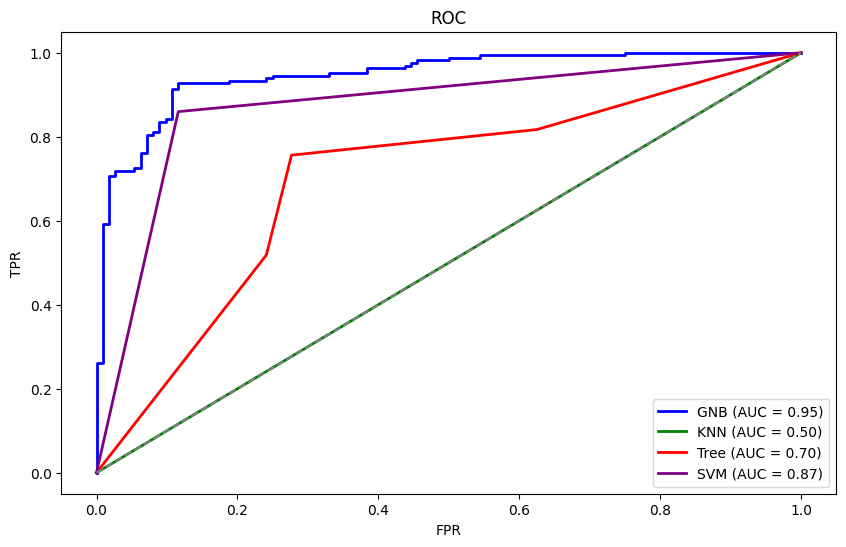

In [ ]:
#ROC=>graphique qui montre la capacité d'un modèle à faire des prédictions correctes.
#AUC=> mesure la qualité de la courbe ROC. Plus l'AUC est proche de 1, mieux le modèle est.

#f1-score fait le balance entre false positive w false negative (exemple)


import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

#probabilité qu'un patient ait la maladie (c'est-à-dire une valeur entre 0 et 1)
y_prob_gnb = gaus.predict_proba(X_test_scaled)[:, 1]  
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]  
y_prob_tree = tree.predict_proba(X_test_scaled)[:, 1] 

# 2. Calculer les courbes ROC et AUC pour chaque modèle
#fpr =>False Positive Rate
#tpr =>True Positive Rate
fpr_gnb, tpr_gnb, _ = roc_curve(y_test, y_prob_gnb)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)

roc_auc_gnb = auc(fpr_gnb, tpr_gnb)
roc_auc_knn = auc(fpr_knn, tpr_knn)
roc_auc_tree = auc(fpr_tree, tpr_tree)

# Calcul des probabilités pour le SVM (en utilisant la distance à l'hyperplan comme probabilité)
y_prob_svm = svm_model.predict(X_test_scaled)  # Approximation directe des distances

# Calcul des courbes ROC pour le SVM
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)


plt.figure(figsize=(10, 6))

plt.plot(fpr_gnb, tpr_gnb, color='blue', lw=2, label=f'GNB (AUC = {roc_auc_gnb:.2f})')
plt.plot(fpr_knn, tpr_knn, color='green', lw=2, label=f'KNN (AUC = {roc_auc_knn:.2f})')
plt.plot(fpr_tree, tpr_tree, color='red', lw=2, label=f'Tree (AUC = {roc_auc_tree:.2f})')
plt.plot(fpr_svm, tpr_svm, color='purple', lw=2, label=f'SVM (AUC = {roc_auc_svm:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

plt.title('ROC')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend(loc='lower right')

plt.show()




In [42]:
# ---Si vous voulez un bon compromis entre la détection des malades et l'évitement des faux positifs,
# le F1-score est souvent la meilleure métrique.
# ---Si la priorité est de maximiser la détection des malades, alors le rappel est important.
# --- Si vous cherchez à comparer la performance des modèles de manière globale, 
# vous pouvez vous fier à l'AUC-ROC.

In [43]:
third_sample = X_test_scaled[2].reshape(1, -1) 

predicted_class = gaus.predict(third_sample)

print(f"La classe prédite pour le troisième échantillon est : {predicted_class[0]}")


La classe prédite pour le troisième échantillon est : 1


In [44]:
from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import GaussianNB
import numpy as np

# Initialiser le modèle GNB
gaus = GaussianNB()

# Effectuer la validation croisée avec 10 folds
cv_scores = cross_val_score(gaus, X_train_scaled, y_train, cv=10, scoring='accuracy')

# Afficher les résultats de la validation croisée
print("Validation Croisée (10 folds) - Scores d'Accuracy:", cv_scores)

# Moyenne et écart-type des scores
print("Moyenne de l'Accuracy:", np.mean(cv_scores))
print("Écart-type de l'Accuracy:", np.std(cv_scores))


Validation Croisée (10 folds) - Scores d'Accuracy: [0.83076923 0.89230769 0.90625    0.859375   0.84375    0.890625
 0.703125   0.90625    0.875      0.78125   ]
Moyenne de l'Accuracy: 0.8488701923076925
Écart-type de l'Accuracy: 0.06097236713003153
